In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import rasterio
import re
import scipy as sp
import sys
sys.path.append(os.path.abspath('../src/'))
from visualize import *
from utils import *
from make_trap_layout import *
from simulate_scr import *

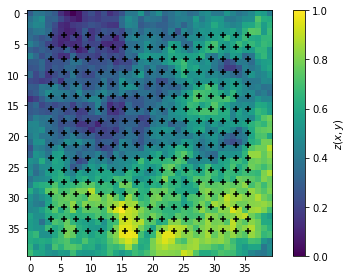

In [2]:
landscape_raster = rasterio.open('../data/simulation/covariate_rasters/lowfrag_covariate.tif')
landscape_ndarr = np.squeeze(np.array(landscape_raster.read()))
trap_loc = create_grid_layout(17, 17, landscape_ndarr)
visualize_trap_layout(landscape_ndarr, trap_loc)

[(26.0, 30.0)]
[[2.8122797710821, 4.26278193108738]]


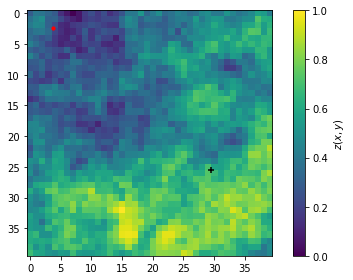

In [31]:
trap_loc_single = list([trap_loc[200]])
print(trap_loc_single)
activity_centers = list(csv.reader(open('../data/simulation/activity_centers/lowfrag_N100_a2225_0_consbio.csv', 'r')))
activity_center_single = list([[eval(activity_centers[14][0]), eval(activity_centers[14][1])]])
print(activity_center_single)
visualize_activity_centers_and_trap_layout(landscape_ndarr, activity_center_single, trap_loc_single)

In [3]:
logfiles_7_7 = ['../logs/'+p for p in os.listdir('../logs/') if '_grid_7_7' in p]

logfiles_9_9 = ['../logs/'+p for p in os.listdir('../logs/') if '_grid_9_9' in p]

logfiles_10_10 = ['../logs/'+p for p in os.listdir('../logs/') if '_grid_10_10' in p]
logfiles_14_14 = ['../logs/'+p for p in os.listdir('../logs/') if '_grid_14_14' in p]


In [4]:
def get_RSE_n0_vals(logfiles):
    RSE_n0 = []
    for lf in logfiles:
        found = False
        lines = list(csv.reader(open(lf, 'r')))
        for l in lines:
            if 'RSE(n0)' in l[0]:
                RSE_n0.append(eval(l[0].split()[-1]))
                found = True
        if not found:
            print(lf)
    return(RSE_n0)

In [5]:
RSE_n0_7_7 = get_RSE_n0_vals(logfiles_7_7)
print(np.mean(RSE_n0_7_7))

RSE_n0_9_9 = get_RSE_n0_vals(logfiles_9_9)
print(np.mean(RSE_n0_9_9))

RSE_n0_10_10 = get_RSE_n0_vals(logfiles_10_10)
print(np.mean(RSE_n0_10_10))
RSE_n0_14_14 = get_RSE_n0_vals(logfiles_14_14)
print(np.mean(RSE_n0_14_14))

0.29181913580246915
0.22359135802469132
0.21114864197530864
0.1977125


In [6]:
len(RSE_n0_9_9)

810

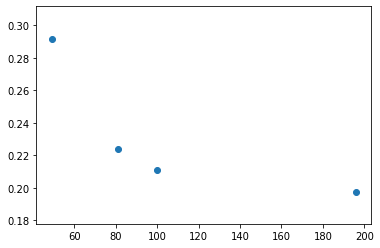

In [7]:
n_traps_grid = [7*7, 9*9, 10*10, 14*14]
RSE_n0_grid = [np.mean(RSE_n0_7_7), np.mean(RSE_n0_9_9), np.mean(RSE_n0_10_10), np.mean(RSE_n0_14_14)]
plt.scatter(n_traps_grid, RSE_n0_grid)
plt.show()

In [9]:
greedy_logfile = list(csv.reader(open('../logs/lowfrag_train_greedy_backward_50.log', 'r')))
num_traps_removed = []
ordered_traps_removed = []
RSE_approx = []
for l in greedy_logfile:
    print(l)
#     if len(l[0].split()) == 1:
#         num_traps_removed.append(eval(l[0]))
#     elif len(l[0].split()) == 2:
#         ordered_traps_removed.append(eval(l[0].split()[0]))
#         RSE_approx.append(eval(l[0].split()[-1]))
# plt.plot([196 - i for i in num_traps_removed], RSE_approx, color='g', label='greedy')
# plt.scatter(n_traps_grid, RSE_n0_grid, marker='x', color='k', label='grid')
# plt.legend(fontsize=12)
# plt.xlabel('Number of Camera Traps', fontsize=14)
# plt.ylabel('RSE($n_0$)', fontsize=14)
# plt.show()

['scenario 0']
['[0.71041896 1.18460117 0.83955864 3.53566062]']
['[0.68377825 1.25123499 0.7713445  3.55670622]']
['[0.67933813 1.17349554 0.81594605 3.58827462]']
['[0.66379772 1.22717278 0.80413976 3.69876401]']
['[0.66379772 1.22717278 0.80413976 3.69876401]']
['[0.66379772 1.22717278 0.80413976 3.69876401]']
['[0.66379772 1.22717278 0.80413976 3.69876401]']
['[0.6277391  1.14672922 0.85807771 3.7775617 ]']
['[0.6277391  1.14672922 0.85807771 3.7775617 ]']
['[0.6277391  1.14672922 0.85807771 3.7775617 ]']
['[0.61094014 1.09014814 0.92475009 4.02582115]']
['[0.58668264 1.07941892 0.96709793 3.86044801]']
['[0.58668264 1.07941892 0.96709793 3.86044801]']
['[0.58668264 1.07941892 0.96709793 3.86044801]']
['[0.58668264 1.07941892 0.96709793 3.86044801]']
['[0.59771304 1.01522067 1.00532945 3.99503549]']
['[0.57543361 1.03631659 0.98925769 4.10951242]']
['[0.56492302 1.00039205 1.02677094 3.98169099]']
['[0.58654256 1.04148063 0.9692355  4.01835004]']
['[0.58654256 1.04148063 0.9692355 

In [10]:
# print(ordered_traps_removed)
# pickle.dump(ordered_traps_removed, open('backward_greedy_budget_50_trap_removal_order.pkl', 'wb'))

[30, 88, 31, 86, 32, 75, 58, 29, 100, 19, 73, 103, 57, 187, 62, 190, 17, 173, 91, 60, 99, 15, 22, 20, 115, 26, 63, 159, 166, 180, 54, 24, 189, 47, 158, 165, 193, 167, 125, 191, 71, 155, 89, 174, 150, 16, 164, 127, 183, 192, 194, 119, 35, 96, 152, 157, 123, 145, 195, 121, 25, 181, 66, 142, 161, 151, 134, 93, 179, 178, 51, 186, 169, 43, 153, 117, 143, 140, 156, 172, 81, 78, 176, 59, 68, 147, 80, 160, 130, 37, 177, 85, 27, 135, 188, 113, 106, 34, 138, 175, 97, 132, 139, 108, 53, 171, 154, 111, 162, 50, 141, 148, 124, 136, 144, 102, 163, 170, 79, 184, 23, 11, 13, 21, 168, 65, 95, 120, 146, 76, 129, 137, 112, 133, 67, 182, 118, 83, 185, 5, 149, 131, 38, 36, 56, 126]


In [10]:
logfiles_greedy_100 = ['../logs/'+p for p in os.listdir('../logs/') if '_remove_96' in p]
logfiles_greedy_81 = ['../logs/'+p for p in os.listdir('../logs/') if '_remove_115' in p]
logfiles_greedy_50 = ['../logs/'+p for p in os.listdir('../logs/') if '_remove_146' in p]


In [11]:
RSE_n0_greedy_100 = get_RSE_n0_vals(logfiles_greedy_100)
print(np.mean(RSE_n0_greedy_100))

RSE_n0_greedy_81 = get_RSE_n0_vals(logfiles_greedy_81)
print(np.mean(RSE_n0_greedy_81))

RSE_n0_greedy_50 = get_RSE_n0_vals(logfiles_greedy_50)
print(np.mean(RSE_n0_greedy_50))

n_traps_greedy = [50, 81, 100]
RSE_n0_greedy = [np.mean(RSE_n0_greedy_50), np.mean(RSE_n0_greedy_81), np.mean(RSE_n0_greedy_100)]


0.2072459259259259
0.2029503703703704
0.169500987654321


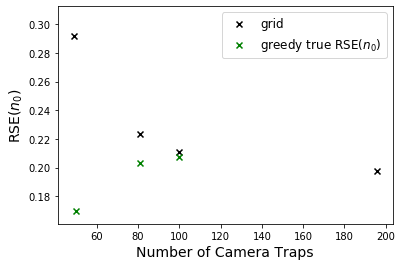

In [13]:
# plt.plot([196 - i for i in num_traps_removed], RSE_approx, color='g', label='greedy')
plt.scatter(n_traps_grid, RSE_n0_grid, marker='x', color='k', label='grid')
plt.scatter(n_traps_greedy, RSE_n0_greedy, marker='x', color='g', label='greedy true RSE($n_0$)')
plt.legend(fontsize=12)
plt.xlabel('Number of Camera Traps', fontsize=14)
plt.ylabel('RSE($n_0$)', fontsize=14)
plt.show()

In [3]:
ordered_traps_removed = pickle.load(open('backward_greedy_budget_50_trap_removal_order.pkl', 'rb'))

In [9]:
pickle.dump(ordered_traps_removed_copypaste, open('backward_greedy_budget_50_trap_removal_order_2.pkl', 'wb'))

In [5]:
ordered_traps_removed_copypaste = [30, 88, 31, 86, 32, 75, 58, 29, 100, 19, 73, 103, 57, 187, 62, 190, 17, 173, 91, 60, 99, 15, 22, 20, 115, 26, 63, 159, 166, 180, 54, 24, 189, 47, 158, 165, 193, 167, 125, 191, 71, 155, 89, 174, 150, 16, 164, 127, 183, 192, 194, 119, 35, 96, 152, 157, 123, 145, 195, 121, 25, 181, 66, 142, 161, 151, 134, 93, 179, 178, 51, 186, 169, 43, 153, 117, 143, 140, 156, 172, 81, 78, 176, 59, 68, 147, 80, 160, 130, 37, 177, 85, 27, 135, 188, 113, 106, 34, 138, 175, 97, 132, 139, 108, 53, 171, 154, 111, 162, 50, 141, 148, 124, 136, 144, 102, 163, 170, 79, 184, 23, 11, 13, 21, 168, 65, 95, 120, 146, 76, 129, 137, 112, 133, 67, 182, 118, 83, 185, 5, 149, 131, 38, 36, 56, 126]

In [13]:
trap_loc_14_14 = [(eval(line[0]), eval(line[1])) for line in csv.reader(open('../data/simulation/trap_locations/lowfrag_covariate_grid_14_14.csv', 'r'))]
trap_loc_7_7 = [(eval(line[0]), eval(line[1])) for line in csv.reader(open('../data/simulation/trap_locations/lowfrag_covariate_grid_7_7.csv', 'r'))]
trap_loc_9_9 = [(eval(line[0]), eval(line[1])) for line in csv.reader(open('../data/simulation/trap_locations/lowfrag_covariate_grid_9_9.csv', 'r'))]

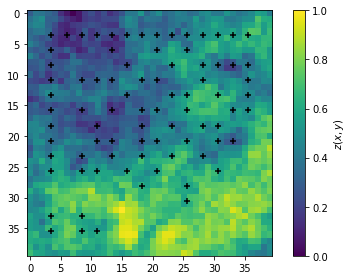

In [14]:
trap_loc_greedy_50 = [v for i, v in enumerate(trap_loc_14_14) if i not in ordered_traps_removed_copypaste[:196-50]]
trap_loc_greedy_81 = [v for i, v in enumerate(trap_loc_14_14) if i not in ordered_traps_removed_copypaste[:196-81]]
visualize_trap_layout(landscape_ndarr, trap_loc_greedy_81)

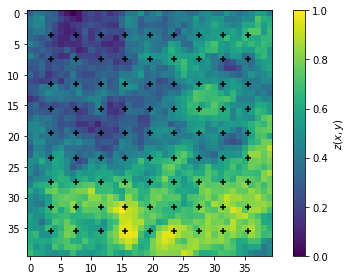

In [15]:
visualize_trap_layout(landscape_ndarr, trap_loc_9_9)

In [22]:
def get_N_hat_abs_err_vals(logfiles):
    N_hat_abs_err = []
    for lf in logfiles:
        N_found = False
        N_hat_found = False
        lines = list(csv.reader(open(lf, 'r')))
        for l in lines:
            if 'N:' in l[0]:
                N = eval(l[0].split()[-1])
                N_found = True
        
            if 'N_hat:' in l[0]:
                N_hat = eval(l[0].split()[-1])
                N_hat_found = True
        if not (N_found and N_hat_found):
            print(lf)
        else:
            N_hat_abs_err.append(np.abs(N_hat - N)/N)
    return(N_hat_abs_err)

In [37]:
Nhat_abs_err_10_10 = get_N_hat_abs_err_vals(logfiles_10_10)
print(np.mean(Nhat_abs_err_10_10))
print(np.std(Nhat_abs_err_10_10))
print('---')
Nhat_abs_err_7_7 = get_N_hat_abs_err_vals(logfiles_7_7)
print(np.mean(Nhat_abs_err_7_7))
print(np.std(Nhat_abs_err_7_7))

0.42741635315126664
0.15294583754066782
---
0.6834016780991166
0.4528746912335105


In [39]:
Nhat_abs_err_greedy_100 = get_N_hat_abs_err_vals(logfiles_greedy_100)
print(np.mean(Nhat_abs_err_greedy_100))
print(np.std(Nhat_abs_err_greedy_100))
print('---')
Nhat_abs_err_greedy_50 = get_N_hat_abs_err_vals(logfiles_greedy_50)
print(np.mean(Nhat_abs_err_greedy_50))
print(np.std(Nhat_abs_err_greedy_50))

0.8227938002013225
0.21338914839626336
---
1.9235713006524593
1.5400519434218634


In [ ]:
result, trace = pickle.load(open('../src/backward_greedy_budget_50_results.pkl', 'rb'))


In [ ]:
n_traps = np.arange(196, 49, -1)
plt.plot(n_traps, trace)
plt.xlim(196, 50)
plt.xlabel('Number of Traps')
plt.ylabel('Estimated RSE')
plt.show()

In [ ]:
pattern = 'lowfrag_N100_a2225_sparse_grid_0'
path_to_logfiles = '../logs/'
files = [f for f in os.listdir(path_to_logfiles) if re.match(pattern, f)]

In [ ]:
N=100
N_hat = []
for f in files:
    lines = open(path_to_logfiles + f, 'r').readlines()
    for l in lines:
        if 'N_hat' in l:
            N_hat.append(eval(l.split('N_hat: ')[-1].strip()))
print(np.mean(N_hat), np.std(N_hat))


In [ ]:
# scipy stats
from scipy.stats import sem
RSE = 100*sem(N_hat)/np.mean(N_hat)
print(RSE)

In [ ]:
# SE / mean
100*(np.std(N_hat)/np.sqrt(len(N_hat)))/np.mean(N_hat)

In [ ]:
import matplotlib.pyplot as plt
plt.hist(N_hat)